In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jdatetime
import matplotlib.ticker as ticker
import seaborn as sns


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
آمار توصیفی
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
6ـ ترند میانگین قیمت اجاره بر حسب ماه‌های قرار گرفتن آگهی‌ها رسم کنید.(دقت کنید که ماه‌ها باید به تاریخ شمسی و خوانا باشند.)
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

In [3]:
df = pd.read_csv("Divar.csv", low_memory=False)


In [27]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
# pd.reset_option('all')

In [4]:
df['cat3_slug'].value_counts()


cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64

In [5]:
df.loc[df['cat2_slug'] == 'residential-rent', 'cat3_slug'].value_counts()

cat3_slug
apartment-rent      211880
house-villa-rent     64678
Name: count, dtype: int64

In [6]:
df.loc[df['cat2_slug'] == 'commercial-rent', 'cat3_slug'].value_counts()

cat3_slug
shop-rent                             45993
office-rent                           21418
industry-agriculture-business-rent     9155
Name: count, dtype: int64

In [7]:
res_rent_df = df[df['cat2_slug'] == "residential-rent"].copy()

In [8]:
res_rent_df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,"26,000,000",NaN,NaN,NaN,NaN,مقطوع,"750,000,000",False,False,"750,000,000",NaN,"26,000,000",NaN,NaN,132,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,NaN
5,5,residential-rent,apartment-rent,ahvaz,mellirah,2024-09-01 00:00:00,NaN,اپارتمان ۱۰۰متری واحد جلو دارای دو اتاق خواب کمددیواری کابینت ام دی اف ابگرمن دیواری هود صفحه‌ای کف کامل موکت پارکینگ اختصاصی دارای دو تراس یکی در حال یکی در اتاق خواب دارای لوکیشن خوب واقع در ملی را خیابون مستفی بین فرشید یک و دو,اپارتمان ۱۰۰متری ملی راه واحد جلو,مقطوع,"6,000,000",NaN,NaN,NaN,NaN,مقطوع,"250,000,000",False,True,"250,000,000","400,000,000","6,000,000",1,NaN,100,NaN,NaN,3,دو,3,2,true,False,True,True,۱۳۸۹,False,NaN,water_heater,NaN,NaN,NaN,NaN,squat,NaN,NaN,NaN,NaN,NaN,NaN,carpet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,11,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,مشاور املاک,‼️‼️ارزنده ترین واحد منطقه ‼️‼️ \n\n✅ 91 متر با 2 خواب بزرگ \n \n✅ بسیار خوش نقشه بدون فضای پرتی \n \n✅ سالن پرده خور با پنجره های قدی\n\n☀️ آفتاب مستقیم عالی \n\n✅ پاسیو (حیاط خلوت) بزرگ\n \n✅ مشاعات تمیز \n \n✅ دسترسی عالی به بوستان گفتگو و حمل و نقل عمومی \n \n⬅️ تخفیف پای قرارداد \n\n☑️با من وفا ، مشاور تخصصی اجاره در منطقه در تماس باشید \n\n ☑️ پایان جستجو شما افتخار ما☑️,گیشا / ۹۱ متر /فرعی زوج مشرف به پارک گفتگو/ ارزنده,مجانی,0,NaN,rent_credit,NaN,NaN,مقطوع,"1,200,000,000",True,True,"1,200,000,000","800,000,000",0,"12,000,000",NaN,91,NaN,NaN,1,دو,5,NaN,true,False,True,True,۱۳۸۵,True,NaN,NaN,NaN,NaN,NaN,NaN,squat_seat,NaN,NaN,south,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,500
17,17,residential-rent,apartment-rent,mahabad,NaN,2024-09-01 00:00:00,شخصی,اجاره یک آپارتمان تعاونی ۱۶ طبقه اول واقع در پجر پایین مسکن مهر ،دارای کابینت و پرده و پکیج و رادیات روی خیابان اصلی,اجاره آپارتمان مسکن مهر,مقطوع,"6,000,000",NaN,rent_credit,NaN,NaN,مقطوع,"100,000,000",False,False,"100,000,000",NaN,"6,000,000",NaN,NaN,75,NaN,NaN,1,دو,NaN,NaN,true,True,True,True,۱۳۹۸,NaN,NaN,package,NaN,NaN,shoofaj,NaN,squat,NaN,NaN,NaN,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
18,18,residential-rent,apartment-rent,shiraz,farhangshahr,2024-08-01 00:00:00,مشاور املاک,✳️بنام یزدان پاک✳️\n\n️دپارتمان تخصصی املاک ایران️\n\n✅دسترسی ایده آل\n✅یکی از بهترین فرعی های منطقه\n✅ساختمان کم واحد وخلوت\n✅آشپزخانه MDF\n✅گازصفحه ای\n✅کاغذدیواری\n✅سرویس ایرانی وفرنگی\n\n✅تاپیدا کردن واحد رویایی خود همراه شما هستیم\n✋برای اطلاع از فایلهای مشابه لطفا تماس بگیرید\n ⬇️آدرس ما\n⬅️قدوسی شرقی خیابان صداوسیما نبش کوچه 13 (کوچه 60 پاسداران),آپارتمان/2خواب/میدان معلم,مقطوع,"15,000,000",NaN,rent_credit,NaN,NaN,مقطوع,"250,000,000",False,False,"250,000,000",NaN,"15,000,000",NaN,NaN,100,NaN,NaN,0,دو,NaN,NaN,NaN,True,True,True,۱۳۹۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500


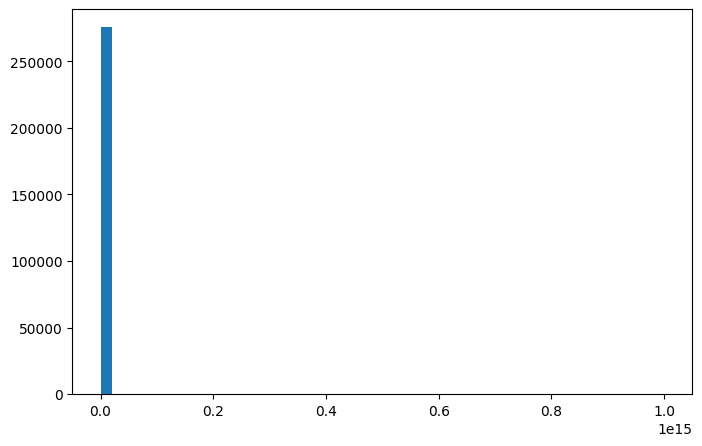

In [11]:
plt.figure(figsize=(8,5))
plt.hist(res_rent_df['rent_value'], bins=50)
plt.show()


In [12]:
res_rent_df['rent_value'].skew()

np.float64(264.8259617783289)

In [13]:
res_rent_df['rent_value'].quantile([0.9, 0.95, 0.99, 0.995, 0.999])

1      22,000,000
1      36,000,000
1     135,000,000
1     250,000,000
1   7,500,000,000
Name: rent_value, dtype: float64

In [15]:
res_rent_df['effective_rent'] = (
    res_rent_df["rent_value"].fillna(0) + 
    0.03 * res_rent_df['credit_value'].fillna(0)
    )

In [16]:
res_rent_df[[
    'rent_value',
    "credit_value",
    'transformable_price',
    'rent_credit_transform',
    'transformable_credit',
    'transformed_credit',
    'transformable_rent',
    'transformed_rent',
    'effective_rent'
]].head(20)

,rent_value,credit_value,transformable_price,rent_credit_transform,transformable_credit,transformed_credit,transformable_rent,transformed_rent,effective_rent
2,"26,000,000","750,000,000",False,False,"750,000,000",NaN,"26,000,000",NaN,"48,500,000"
5,"6,000,000","250,000,000",True,False,"250,000,000","400,000,000","6,000,000",1,"13,500,000"
11,0,"1,200,000,000",True,True,"1,200,000,000","800,000,000",0,"12,000,000","36,000,000"
17,"6,000,000","100,000,000",False,False,"100,000,000",NaN,"6,000,000",NaN,"9,000,000"
18,"15,000,000","250,000,000",False,False,"250,000,000",NaN,"15,000,000",NaN,"22,500,000"
21,"100,000","900,000,000",True,True,"900,000,000","200,000,000","100,000","21,000,000","27,100,000"
23,"100,000","1,000,000,000",False,False,"1,000,000,000",NaN,"100,000",NaN,"30,100,000"
27,"7,000,000","110,000,000",False,False,"110,000,000",NaN,"7,000,000",NaN,"10,300,000"
36,"15,000,000","150,000,000",False,False,"150,000,000",NaN,"15,000,000",NaN,"19,500,000"
37,"6,000,000","600,000,000",False,False,"600,000,000",NaN,"6,000,000",NaN,"24,000,000"


In [17]:
res_rent_df['effective_rent'].describe()

count                 276,558
mean           22,601,604,587
std         2,541,876,033,766
min                         0
25%                 8,500,000
50%                14,000,000
75%                26,000,000
max     1,029,999,999,999,999
Name: effective_rent, dtype: float64

In [18]:
res_rent_df = res_rent_df[res_rent_df['effective_rent'] > 0]

In [19]:
Q1 = res_rent_df['effective_rent'].quantile(0.25)
Q3 = res_rent_df['effective_rent'].quantile(0.75)

IQR = Q3 - Q1

In [20]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [21]:
res_rent_df_clean = res_rent_df [
    (res_rent_df['effective_rent'] >= lower) &
    (res_rent_df['effective_rent'] <= upper) 

]

In [22]:
res_rent_df_clean["effective_rent"].mean()

np.float64(16184266.543092094)

In [23]:
res_rent_df_clean = res_rent_df_clean[
    res_rent_df_clean['effective_rent'] >= 1_000_000
]

In [25]:
res_rent_df_clean['created_at_month'] = pd.to_datetime(res_rent_df_clean['created_at_month'])

In [26]:
res_rent_df_clean['jalali_month'] = res_rent_df_clean["created_at_month"].apply(

    lambda x: jdatetime.date.fromgregorian(date=x).strftime("%Y-%m")
)

In [27]:
monthly_rent = (

    res_rent_df_clean.groupby('jalali_month')['effective_rent']
    .mean()
    .reset_index()
)

In [28]:
monthly_rent['jalali_label'] = monthly_rent['jalali_month'].apply(
    
    lambda x: f"{jdatetime.date(int(x[:4]), int(x[5:7]), 1).strftime('%B')} {x[:4]}"
)

In [29]:
monthly_rent = monthly_rent.sort_values('jalali_month')

In [30]:
print(res_rent_df_clean['jalali_month'].value_counts().sort_index())

jalali_month
1401-03        1
1402-04        1
1402-06        2
1402-08        3
1402-09        2
1402-10       12
1402-11       16
1402-12       38
1403-01      427
1403-02    20109
1403-03    33938
1403-04    37474
1403-05    38655
1403-06    34310
1403-07    31728
1403-08    26463
1403-09    23680
1403-10      172
1403-11       10
Name: count, dtype: int64


In [31]:
res_rent_df_clean_plot = res_rent_df_clean[

    (res_rent_df_clean['jalali_month'] >= '1403-02')&
    (res_rent_df_clean['jalali_month'] <= '1403-09')


].copy()

In [32]:
res_rent_df_clean_plot['jalali_month'].value_counts().sort_index()

jalali_month
1403-02    20109
1403-03    33938
1403-04    37474
1403-05    38655
1403-06    34310
1403-07    31728
1403-08    26463
1403-09    23680
Name: count, dtype: int64

In [33]:
monthly_rent_plot = (

    res_rent_df_clean_plot.groupby('jalali_month')['effective_rent']
    .mean()
    .reset_index()
)

In [34]:
monthly_rent_plot['jalali_label'] = monthly_rent_plot['jalali_month'].apply(
    
    lambda x: f"{jdatetime.date(int(x[:4]), int(x[5:7]), 1).strftime('%B')} {x[:4]}"
)

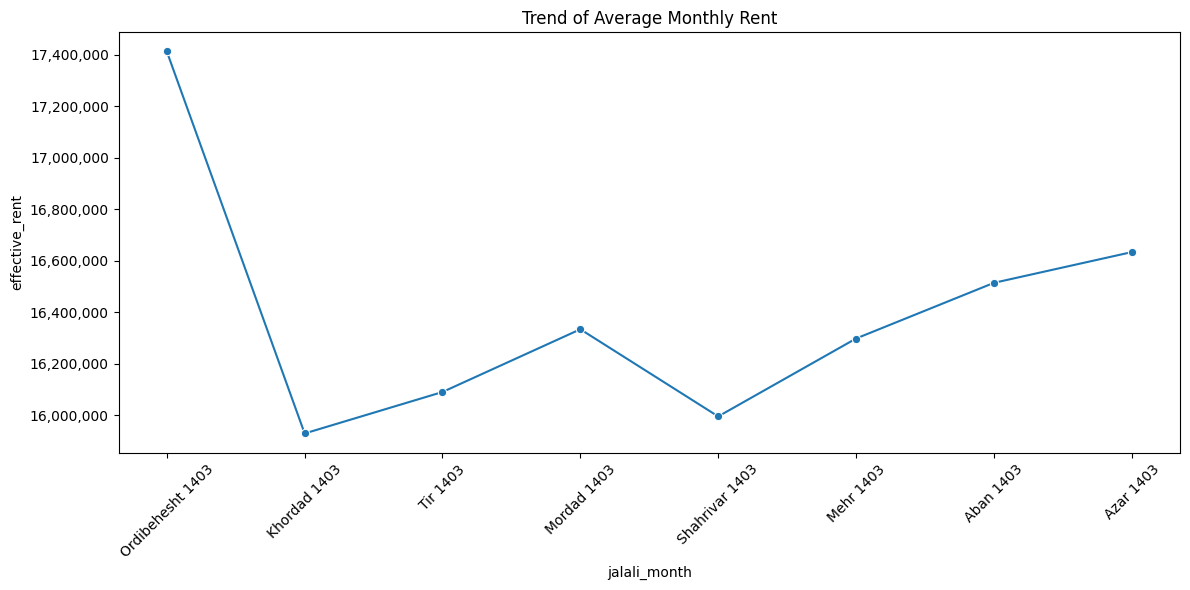

In [36]:

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_rent_plot, 
    x="jalali_month", 
    y="effective_rent", 
    marker="o"
)

plt.xticks(
    ticks=range(len(monthly_rent_plot)), 
    labels=monthly_rent_plot["jalali_label"], 
    rotation=45
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Trend of Average Monthly Rent")
plt.tight_layout()
plt.show()

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
پس از پردازش اطلاعات و حذف ماه هایی که آگهی هایی بسیار بسیار کمی از آنها ثبت شده نمودار روند تغییرات میانگین اجاره بها از اردیبهشت 1403 تا آذرماه آن سال بشکل بالا رسم شد. 
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
7_ در طول زمان قیمت‌های اسمی افزایش پیدا می‌کنند اما این افزایش لزوما به معنی بالارفتن ارزش واقعی ملک نیست و می‌تواند ناشی از تورم باشد. به ازای میانگین مبلغ قیمت(price_value) در سال‌های ۱۴۰۰ تا ۱۴۰۳ قیمت حقیقی را محاسبه کنید و بررسی کنید ترند قیمت حقیقی چگونه است.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

In [37]:
res_sel  = df.loc[df['cat2_slug'] == "residential-sell", ['created_at_month', 'price_value']].copy()

In [38]:
df['cat2_slug'].value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [39]:

res_sel['created_at_month'] = pd.to_datetime(res_sel['created_at_month'], errors='coerce')

res_sel['year_shamsi'] = res_sel['created_at_month'].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).year if pd.notnull(x) else None
)

res_sel = res_sel[res_sel['year_shamsi'].isin([1400, 1401, 1402, 1403])]

In [40]:
res_sel['year_shamsi'].value_counts()

year_shamsi
1403    554514
1402      4134
1401        53
1400         5
Name: count, dtype: int64

In [ ]:

cpi = {
    1400: 100.0,
    1401: 153.1,
    1402: 225.6,
    1403: 306.4
}

base_year = 1403
cpi_base = cpi[base_year]

res_sel['cpi_year'] = res_sel['year_shamsi'].map(cpi)

res_sel['real_price'] = res_sel['price_value'] * (cpi_base / res_sel['cpi_year'])

trend_df = res_sel.groupby('year_shamsi')[['price_value', 'real_price']].mean().reset_index()

trend_df.columns = ['Year', 'Mean Nominal Price', 'Mean Real Price (1403 Base)']

res_sel.drop(columns=['cpi_year'], inplace=True)

print(trend_df)


   Year  Mean Nominal Price  Mean Real Price (1403 Base)
0  1400       1,066,666,667                3,268,266,667
1  1401      17,497,517,730               35,017,893,094
2  1402       7,539,123,304               10,239,305,764
3  1403      16,966,104,064               16,966,104,064


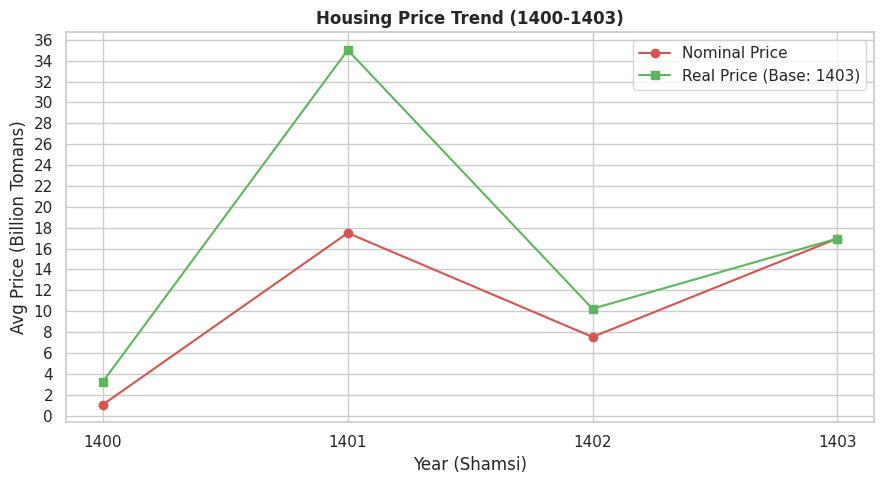

In [ ]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

nominal_b = trend_df['Mean Nominal Price'] / 1e9
real_b = trend_df['Mean Real Price (1403 Base)'] / 1e9
years = trend_df['Year'].astype(str)

plt.plot(years, nominal_b, marker='o', color='#d9534f', label='Nominal Price')
plt.plot(years, real_b, marker='s', color='#5cb85c', label='Real Price (Base: 1403)')

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(20))
plt.title('Housing Price Trend (1400-1403)', fontsize=12, weight='bold')
plt.xlabel('Year (Shamsi)')
plt.ylabel('Avg Price (Billion Tomans)')
plt.legend()

plt.tight_layout()
plt.show()


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
«تحلیل ترند قیمت حقیقی (Real Price Trend):

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
با مقایسه قیمت اسمی و قیمت حقیقی (با سال پایه ۱۴۰۳)، رفتارهای متفاوتی در طول زمان مشاهده می‌شود:

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
۱. اثر تورم (Rebasing): با تبدیل قیمت‌ها به ارزش سال ۱۴۰۳، قیمت‌های سال‌های قبل تعدیل مثبتی داشتند. برای مثال، ارزش واقعی میانگین قیمت سال ۱۴۰۰ از ۱ میلیارد تومان اسمی به ۳.۲ میلیارد تومان حقیقی افزایش یافته است که قدرت خرید واقعی آن دوره را نشان می‌دهد.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
۲. غیرقابل اتکا بودن داده‌های ۱۴۰۰ و ۱۴۰۱: روند حرکتی قیمت‌ها بین سال‌های ۱۴۰۰ تا ۱۴۰۲ نوسانات بسیار شدیدی نشان می‌دهد (جهش شدید در ۱۴۰۱ و سپس افت در ۱۴۰۲). این نوسان شدید ناشی از رفتار واقعی بازار مسکن نیست، بلکه به دلیل تعداد بسیار کم نمونه‌ها (عدم توازن داده‌ها) در این دو سال است که باعث شده داده‌های پرت (Outliers) میانگین را به شدت منحرف کنند.



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
۳. ترند واقعی (۱۴۰۲ به ۱۴۰۳): در بازه زمانی ۱۴۰۲ تا ۱۴۰۳ که حجم داده‌ها ثبات بیشتری دارد، مشاهده می‌کنیم که میانگین قیمت اسمی از ۷.۵ میلیارد تومان به ۱۶.۹ میلیارد تومان افزایش یافته است. قیمت حقیقی نیز در این دوره از ۱۰.۲ میلیارد تومان به ۱۶.۹ میلیارد تومان رسیده است. این یعنی حتی پس از حذف اثر تورم، ارزش واقعی املاک رشد داشته است و این افزایش قیمت صرفاً ناشی از تورم عمومی نبوده، بلکه بخش مسکن رشد ارزش حقیقی را تجربه کرده است.


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
آزمون فرض
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در دسته‌بندی امکانات موجود در آگهی‌ها می‌توانیم آنها را به دو دسته‌ی امکانات لاکچری(استخر، باربیکیو، سونا، جکوزی) و امکانات غیر لاکچری تقسیم کنیم. فرضیه‌ی ما این است که میانگین مبلغ قیمت برای وجود ویژگی‌های لاکچری افزایش چشم‌گیری دارد. اما آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد؟
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

In [ ]:

df_clean = df[df['price_value'].notna() & (df['price_value'] > 0)].copy()


In [ ]:

Q1 = df_clean['price_value'].quantile(0.25)
Q3 = df_clean['price_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df_clean[
    (df_clean['price_value'] >= lower_bound) &
    (df_clean['price_value'] <= upper_bound)
]


In [32]:
df_no_outliers['log_price'] = np.log(df_no_outliers['price_value'])


In [33]:
lux_cols = ['has_pool', 'has_jacuzzi', 'has_sauna', 'has_barbecue']

lux_mask = df_no_outliers[lux_cols].isin([True]).any(axis=1)
non_lux_mask = df_no_outliers[lux_cols].isin([False]).all(axis=1)

df_lux = df_no_outliers[lux_mask].copy()
df_non_lux = df_no_outliers[non_lux_mask].copy()


In [34]:
from scipy.stats import ttest_ind

lux_log = df_lux['log_price'].dropna()
non_lux_log = df_non_lux['log_price'].dropna()

t_stat, p_value = ttest_ind(lux_log, non_lux_log, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 9.819235773645556
p-value: 1.0964123343056526e-22


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
«پس از پاک‌سازی داده‌های پرت قیمت  و اعمال تبدیل لگاریتمی برای تعدیل چولگی توزیع قیمت، آزمون tt دو نمونه مستقل با واریانس‌های نامساوی ( t-test) انجام شد. نتایج نشان داد که املاک دارای حداقل یکی از امکانات لاکچری (استخر، سونا، جکوزی، باربیکیو) به طور معناداری گران‌تر از املاک فاقد این امکانات هستند (t=9.82 , p≈1.1×10−22). این آزمون فرضیه تأثیر مثبت امکانات لاکچری بر ارزش ملک را با سطح اطمینان بیش از ۹۹٪ تأیید می‌کند.»

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<font face="vazir" color="#0099cc">
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
. اما آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد؟
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

In [47]:
non_lux_cols = ['has_elevator', 'has_warehouse', 'has_parking']

In [54]:
non_lux_mask = df_no_outliers[non_lux_cols].isin([True]).any(axis=1)

In [49]:
without_non_lux_mask = df_no_outliers[non_lux_cols].isin([False]).all(axis=1)

In [50]:
df_non_lux = df_no_outliers[non_lux_mask].copy()
df_without_non_lux = df_no_outliers[without_non_lux_mask].copy()

In [51]:
non_lux_log = df_non_lux['log_price'].dropna()
without_non_lux_log = df_without_non_lux['log_price'].dropna()

In [52]:
t_stat, p_value = ttest_ind(non_lux_log, without_non_lux_log, equal_var=False)

In [53]:

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 34.8717966918503
p-value: 5.3475239869283614e-254


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
نتایج نشان داد که وجود حداقل یکی از این امکانات با افزایش بسیار معنادار میانگین قیمت همراه است (t = 34.87، p ≈ 5.34 × 10⁻²⁵⁴). این مقدار بسیار کوچک p-value نشان می‌دهد که اختلاف میانگین قیمت کاملاً معنادار بوده و به هیچ وجه نمی‌توان آن را ناشی از تصادف دانست. بنابراین امکانات غیرلاکچری نقش اساسی و قوی در ارزش‌گذاری ملک دارند.»

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
شدت اثر این امکانات حتی بیشتر از امکانات لاکچری مثل استخر و سونا است.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
    داشتن پارکینگ تقریباً یک الزام شهری است و نبود آن ارزش ملک را به شدت کاهش می‌دهد.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
 آسانسور در ساختمان‌های چند طبقه یک نیاز اساسی است.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
    انباری هم یک ویژگی کاربردی و پرتکرار است.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=5 color=green>
برخلاف امکانات لاکچری که «لوکس» هستند، این امکانات غیرلاکچری نیازی پایه‌ای محسوب می‌شوند و تاثیرشان بر قیمت معمولاً پایدار و قوی است.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>